In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio

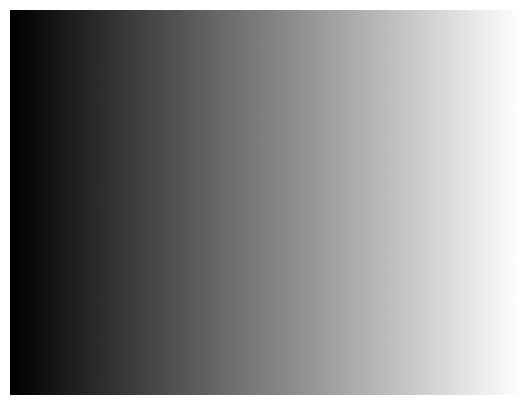

Tamaño de la imagen: (389, 515)


In [11]:
alto = 389
ancho = 515

img = np.zeros((alto, ancho), dtype=np.uint8)

for i in range(alto):
    for j in range(ancho):
        img[i, j] = int((j / (ancho - 1)) * 255)

plt.figure(figsize=(8, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Tamaño de la imagen:", img.shape)

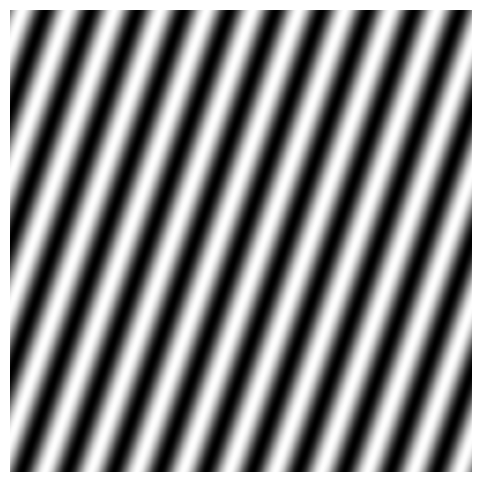

Tamaño de la imagen: (400, 400)


In [12]:
alto = 400
ancho = 400

x = np.linspace(0, 1, ancho)
y = np.linspace(0, 1, alto)

X, Y = np.meshgrid(x, y)

frecuencia = 10
angulo = 0.35

patron = 127.5 * (1 + np.sin(2 * np.pi * frecuencia * (X + angulo * Y)))
patron = patron.astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(patron, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

print("Tamaño de la imagen:", patron.shape)

In [13]:
# Lea las imágenes
lena = imageio.imread('/content/Ref1.png')
tiger = imageio.imread('/content/Ref2.png')

# Asegurar 3 canales
if lena.shape[-1] == 4:
    lena = lena[:, :, :3]

if tiger.shape[-1] == 4:
    tiger = tiger[:, :, :3]

# Redimensionar ambas al mismo tamaño
alto = min(lena.shape[0], tiger.shape[0])
ancho = min(lena.shape[1], tiger.shape[1])

lena = cv2.resize(lena, (ancho, alto))
tiger = cv2.resize(tiger, (ancho, alto))

print("Lena:", lena.shape)
print("Tiger:", tiger.shape)

Lena: (619, 620, 3)
Tiger: (619, 620, 3)


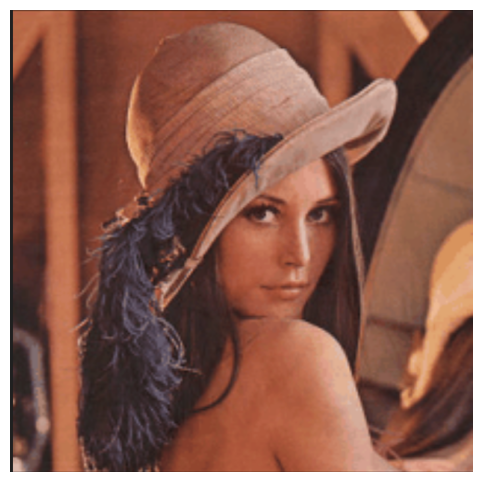

GIF guardado como ejercicio3.gif


In [15]:
frames = []
num_frames = 25

lena_f = lena.astype(np.float32)
tiger_f = tiger.astype(np.float32)

for k in range(num_frames):
    alpha = k / (num_frames - 1)
    frame = ((1 - alpha) * lena_f + alpha * tiger_f).astype(np.uint8)
    frames.append(frame)

for k in range(num_frames - 2, 0, -1):
    alpha = k / (num_frames - 1)
    frame = ((1 - alpha) * lena_f + alpha * tiger_f).astype(np.uint8)
    frames.append(frame)

imageio.mimsave('ejercicio3.gif', frames, duration=0.08)

plt.figure(figsize=(6, 6))
plt.imshow(frames[0])
plt.axis('off')
plt.show()

print("GIF guardado como ejercicio3.gif")

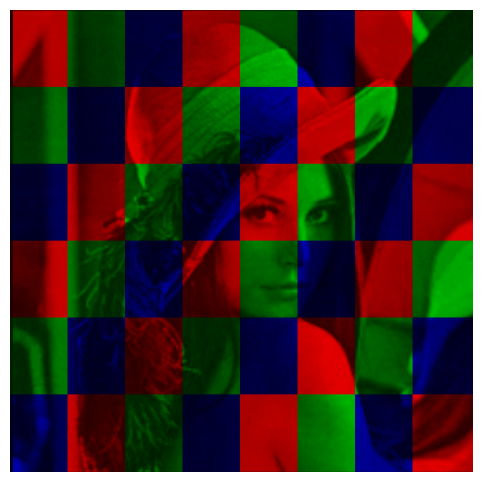

In [16]:


filas_bloques = 6
cols_bloques = 8

bloque_h = alto // filas_bloques
bloque_w = ancho // cols_bloques

salida = np.zeros_like(lena)

colores = [
    np.array([1, 0, 0]),  # rojo
    np.array([0, 1, 0]),  # verde
    np.array([0, 0, 1])   # azul
]

for bi in range(filas_bloques):
    for bj in range(cols_bloques):
        color = colores[(bi + bj) % 3]

        y_ini = bi * bloque_h
        y_fin = alto if bi == filas_bloques - 1 else (bi + 1) * bloque_h

        x_ini = bj * bloque_w
        x_fin = ancho if bj == cols_bloques - 1 else (bj + 1) * bloque_w

        for i in range(y_ini, y_fin):
            for j in range(x_ini, x_fin):
                for c in range(3):
                    salida[i, j, c] = lena[i, j, c] * color[c]

plt.figure(figsize=(8, 6))
plt.imshow(salida)
plt.axis('off')
plt.show()

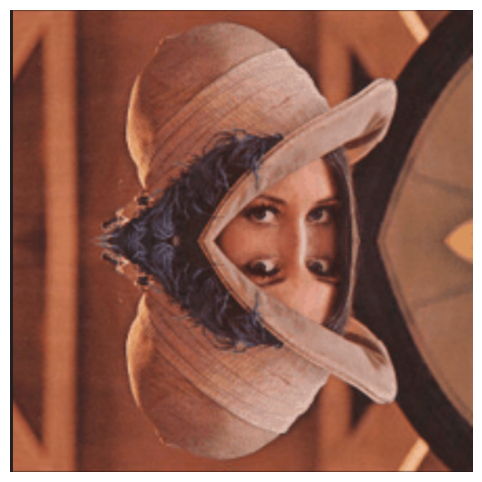

In [18]:
resultado = np.zeros_like(lena)

cy = alto // 2

for i in range(alto):
    for j in range(ancho):
        for c in range(3):
            if i <= cy:
                resultado[i, j, c] = lena[i, j, c]
            else:
                ni = 2 * cy - i
                if 0 <= ni < alto:
                    resultado[i, j, c] = lena[ni, j, c]

plt.figure(figsize=(8, 6))
plt.imshow(resultado)
plt.axis('off')
plt.show()